In [1]:
from blackjack.blackjack_round import BJRound, BJStage, BJRules
from blackjack.actions import PlayerAction, DealerAction
from blackjack.cards import Card, Rank
import numpy as np
import time
import logging
from datetime import datetime
import os
from logging import FileHandler
import tqdm
from collections import deque
from blackjack.shoe import ProbabilisticRankShoe
import time
from blackjack.game_tree import BJTreeNode, MonteCarloNode
import datetime
import matplotlib.pyplot as plt

In [2]:
rules = BJRules(
    dealer_checks_blackjack=True,
    dealer_hits_soft_17=False,
    allow_late_surrender=False,
    allow_early_surrender_on_ten=False,
    allow_early_surrender_on_ace=False,
    allow_early_surrender_on_all=False,
    dealer_shows_card_on_surrender=False,
    allow_insurance_vs_ace=True,
    natural_blackjack_payout=3/2,
    surrender_payout=1/2,
    insurance_payout=2/1,
    max_splits_allowed=1,
    allow_action_on_split_aces=True,
    allow_double_after_split=True,
    allow_double_on_soft=True,
    allow_split_different_tens=True,
    no_natural_bj_on_split=True
)

In [3]:
def get_value(bj_round: BJRound, shoe: ProbabilisticRankShoe):
    if bj_round.get_stage() == BJStage.ROUND_OVER:
        return bj_round.get_player_value()


    if bj_round.need_card():
        possible_card_ranks = bj_round.get_possible_next_card_ranks()
        possible_values = set([r.rank_value() for r in possible_card_ranks])
        card_value_probabilities = shoe.get_rank_value_probabilities(possible_values)
        game_values = []
        game_value_prob = []
        for rv, p in card_value_probabilities.items():
            if p == 0:
                continue
            card = Card(Rank.from_value(rv))

            bj_round_copy = bj_round.copy()
            shoe_copy = shoe.copy()
            bj_round_copy.take_card(card)
            shoe_copy.burn_card(card)

            game_values.append(get_value(bj_round_copy, shoe_copy))
            game_value_prob.append(p)
        return np.dot(game_values, game_value_prob)
    

    if bj_round.need_player_action():
        actions = bj_round.get_available_actions()
        action_values = []
        for a in actions:
            bj_round_copy = bj_round.copy()
            bj_round_copy.take_action(a)
            action_values.append(get_value(bj_round_copy, shoe))
        return max(action_values)
    
    if bj_round.need_dealer_action():
        assert bj_round.get_stage() == BJStage.DEALER_CHECK_BJ
        actions = bj_round.get_available_actions()
        
        dealer_value = bj_round.dealer_hand.best_value()
        rv_prob = shoe.get_rank_value_probabilities()

        shoe_no_bj = shoe.copy()
        if dealer_value == 11:
            p_dealer_blackjack = rv_prob[10]
            shoe_no_bj.lock_dealer_card_not_ten()
        elif dealer_value == 10:
            p_dealer_blackjack = rv_prob[11]
            shoe_no_bj.lock_dealer_card_not_ace()
        else:
            raise RuntimeError("Dealer cannot check blackjack with value other than 10 or 11")
        
        bj_round_dealer_bj = bj_round.copy()
        bj_round_dealer_bj.take_action(DealerAction.CONFIRM_BLACKJACK)

        bj_round_no_dealer_bj = bj_round.copy()
        bj_round_no_dealer_bj.take_action(DealerAction.CONFIRM_NO_BLACKJACK)

        p_dealer_no_blackjack = 1 - p_dealer_blackjack
        value = (
            p_dealer_blackjack * get_value(bj_round_dealer_bj, shoe) +
            p_dealer_no_blackjack * get_value(bj_round_no_dealer_bj, shoe_no_bj)
        )

        return value



In [4]:
def get_nodes_on_the_level(root_node, level):
    nodes = []
    queue = deque()
    queue.append((root_node, 0))
    while queue:
        node, node_level = queue.popleft()
        if node_level == level:
            nodes.append(node)
        elif node_level < level:
            for child in node.children:
                queue.append((child, node_level + 1))
    return nodes

In [5]:
bj_round = BJRound(rules)
shoe = ProbabilisticRankShoe(8)
bj_round.start_round(10)

# cards = [
#     Card(Rank.TEN),
#     Card(Rank.TEN),
#     Card(Rank.SIX)  
# ]

cards = [
    Card(Rank.TEN),
    Card(Rank.SIX),
    Card(Rank.ACE)  
]

bj_round.take_card(cards[0])
bj_round.take_card(cards[1])
bj_round.take_card(cards[2])

shoe.burn_rank_value(cards[0].rank_value())
shoe.burn_rank_value(cards[1].rank_value())
shoe.burn_rank_value(cards[2].rank_value())

root_node = BJTreeNode(bj_round, shoe, monte_carlo_depth=5)

print(str(bj_round))

Last card: A.
Dealer A.X
Player T.6.(16)[$10]


In [6]:
for i in range(50):
    t0 = time.time()
    root_node.build_tree_layer(depth=i)
    t1 = time.time()
    dt = datetime.timedelta(seconds=t1 - t0)
    print(f"Depth {i} built in {dt}")
    if root_node.tree_completed():
        print("Tree completed")
        break

Depth 0 built in 0:00:00.000003
Depth 1 built in 0:00:00.000173
Depth 2 built in 0:00:00.000251
Depth 3 built in 0:00:00.000915
Depth 4 built in 0:00:00.006975
Depth 5 built in 0:00:00.053965
Depth 6 built in 0:00:05.369431
Depth 7 built in 0:00:00.197285
Depth 8 built in 0:00:00.064304
Depth 9 built in 0:00:00.064936
Tree completed


In [7]:
print(root_node.get_value())

-5.467566821034815


In [8]:
values = []

values.append(root_node.get_value())

for i in tqdm.tqdm(range(100)):
    root_node.resample_player_cards()
    values.append(root_node.get_value())
mean_value = np.mean(values)

100%|██████████| 100/100 [00:30<00:00,  3.30it/s]


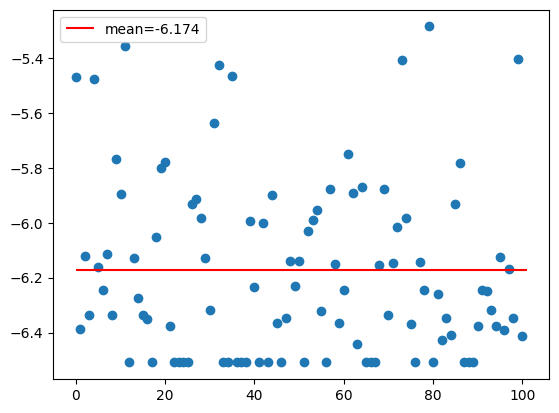

In [9]:
f, ax = plt.subplots()
ax.scatter(range(len(values)), values)
ax.hlines(mean_value, xmin=0, xmax=len(values), color="red", label=f"mean={mean_value:.3f}")
ax.legend()

In [10]:
np.min(values), np.max(values)

(np.float64(-6.509208020874961), np.float64(-5.2844965796093))

In [11]:
for lvl in range(25):
    level_nodes = get_nodes_on_the_level(root_node, lvl)
    print(f"Level {lvl} has {len(level_nodes)} nodes")
    finished = False
    for n in level_nodes:
        if n.bj_round.get_stage() == BJStage.ROUND_OVER:
            continue
        elif isinstance(n, MonteCarloNode):
            print(f"MonteCarloNode found on level {lvl}")
            finished = True
            break
        else:
            break
    
    if finished:
        break

Level 0 has 1 nodes
Level 1 has 2 nodes
Level 2 has 4 nodes
Level 3 has 8 nodes
Level 4 has 58 nodes
Level 5 has 404 nodes
MonteCarloNode found on level 5


In [12]:
from collections import Counter
count = Counter()

player_card_nodes = []
player_action_nodes = []
for node in level_nodes:
    stage = node.bj_round.get_stage()
    count[stage] += 1
    if stage == BJStage.PLAYER_CARD:
        player_card_nodes.append(node)
    if stage == BJStage.PLAYER_ACTION:
        player_action_nodes.append(node)



In [13]:
count

Counter({<BJStage.DEALER_CARD: 7>: 218,
         <BJStage.ROUND_OVER: 8>: 178,
         <BJStage.PLAYER_CARD: 5>: 8})

In [16]:
for i, n in enumerate(player_card_nodes):
    print(f"idx = {i}")
    print(f"Value = {n.get_value()}")
    print(str(n.bj_round))
    print()

idx = 0
Value = -15.0
Last action: HIT
Dealer A.X (insurance 5.0) (checked - no bj)
Player T.6.2.(18)[$10]

idx = 1
Value = -15.0
Last action: HIT
Dealer A.X (insurance 5.0) (checked - no bj)
Player T.6.3.(19)[$10]

idx = 2
Value = -15.0
Last action: HIT
Dealer A.X (insurance 5.0) (checked - no bj)
Player T.6.4.(20)[$10]

idx = 3
Value = -2.3
Last action: HIT
Dealer A.X (insurance 5.0) (checked - no bj)
Player T.6.A.(17)[$10]

idx = 4
Value = -10.0
Last action: HIT
Dealer A.X (checked - no bj)
Player T.6.2.(18)[$10]

idx = 5
Value = -10.0
Last action: HIT
Dealer A.X (checked - no bj)
Player T.6.3.(19)[$10]

idx = 6
Value = 9.0
Last action: HIT
Dealer A.X (checked - no bj)
Player T.6.4.(20)[$10]

idx = 7
Value = -10.0
Last action: HIT
Dealer A.X (checked - no bj)
Player T.6.A.(17)[$10]



In [18]:
this_node = player_card_nodes[-1].parent
this_node.build_tree()

print(f"this_node Value = {this_node.get_value()}")
print(str(this_node.bj_round))
first_value = this_node.get_value()

this_node Value = -5.2
Last card: A.
Dealer A.X (checked - no bj)
Player T.6.A.(17)[$10]


In [19]:
for i in range(100):
    changed = this_node.resample_player_cards()
    if this_node.get_value() == first_value:
        continue
    print(changed, this_node.get_value())
    print("-" * 32)

    # for i in range(len(this_node.children)):
    #     p = this_node.children_prob[i]
    #     ch = this_node.children[i]
    #     print(f"Value = {ch.get_value()}")
    #     print(f"Probability = {p}")
    #     print(str(ch.bj_round))
    #     print()
    # print("-" * 32)


True 6.2
--------------------------------
True 2.4
--------------------------------
True 2.4
--------------------------------
True 7.1
--------------------------------
True 9.5
--------------------------------
True -0.6
--------------------------------
True 2.4
--------------------------------
True -2.1
--------------------------------
True 9.2
--------------------------------
True 5.5
--------------------------------
True 9.5
--------------------------------
True 6.8
--------------------------------
True 6.3
--------------------------------
True 9.5
--------------------------------
True 9.2
--------------------------------
True 6.5
--------------------------------
True -1.6
--------------------------------
True 6.7
--------------------------------
True 3.7
--------------------------------
True 6.2
--------------------------------
True -1.6
--------------------------------
True 6.6
--------------------------------
True 5.7
--------------------------------
True 9.7
---------------------

In [20]:
# this_node.has_completed_tree = False
# this_node.has_built_children = False
# this_node.children_prob = []
# this_node.children = []

In [21]:
print(this_node.children[1].children[-1].bj_round)

Last card: A.
Dealer A.X (checked - no bj)
Player T.6.A.A.(18)[$10]


In [ ]:
for i in range(100):
    this_node.resample_player_cards()
    children_of_interest = this_node.children[1].children[-1].children

    # if this_node.children_prob[1] == 0:
    #    continue
    
    # print(this_node.get_value())
    # print([f"{ch.get_value():.2f}" for ch in this_node.children])
    print(this_node.children_prob)

6.7
['-6.00', '6.70']
[0, 1]
7.2
['-6.00', '7.20']
[0, 1]
6.3
['-6.00', '6.30']
[0, 1]
3.0
['-6.00', '3.00']
[0, 1]
9.1
['-6.00', '9.10']
[0, 1]
3.1
['-6.00', '3.10']
[0, 1]
9.0
['-6.00', '9.00']
[0, 1]
9.4
['-6.00', '9.40']
[0, 1]
9.2
['-6.00', '9.20']
[0, 1]
-2.3
['-6.00', '-2.30']
[0, 1]
6.4
['-6.00', '6.40']
[0, 1]
6.4
['-6.00', '6.40']
[0, 1]
-2.1
['-6.00', '-2.10']
[0, 1]
7.2
['-6.00', '7.20']
[0, 1]
9.0
['-6.00', '9.00']
[0, 1]
9.6
['-6.00', '9.60']
[0, 1]
6.5
['-6.00', '6.50']
[0, 1]
-0.8
['-6.00', '-0.80']
[0, 1]
9.4
['-6.00', '9.40']
[0, 1]
3.3
['-6.00', '3.30']
[0, 1]
2.1
['-6.00', '2.10']
[0, 1]
9.1
['-6.00', '9.10']
[0, 1]
9.2
['-6.00', '9.20']
[0, 1]
2.8
['-6.00', '2.80']
[0, 1]
-0.9
['-6.00', '-0.90']
[0, 1]
6.5
['-6.00', '6.50']
[0, 1]
9.2
['-6.00', '9.20']
[0, 1]
-1.3
['-6.00', '-1.30']
[0, 1]
-1.4
['-6.00', '-1.40']
[0, 1]
6.0
['-6.00', '6.00']
[0, 1]
-0.4
['-6.00', '-0.40']
[0, 1]
9.1
['-6.00', '9.10']
[0, 1]
9.2
['-6.00', '9.20']
[0, 1]


In [28]:
this_node.resample_player_cards()

for ch in this_node.children:
    print(ch.get_value())
    print(str(ch.bj_round))
    print()

-6.0
Last action: STAND
Dealer A.X (checked - no bj)
Player T.6.A.(17 - stand)[$10]

8.8
Last action: HIT
Dealer A.X (checked - no bj)
Player T.6.A.(17)[$10]



In [ ]:

print(this_node.children[0].get_value())

-146.51649122807015


In [ ]:
print(this_node.children)

[<blackjack.game_tree.BJTreeNode object at 0x7bb10c9a6cc0>, <blackjack.game_tree.BJTreeNode object at 0x7bb10c9a7d70>]
